In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Load in data
cellranger = pd.read_csv('20240621_cellranger_summary_stats.csv')

# Explore the data
print(cellranger.columns)

Index(['ID', 'Estimated Number of Cells', 'Mean Reads per Cell',
       'Median Genes per Cell', 'Number of Reads', 'Valid Barcodes',
       'Sequencing Saturation', 'Q30 Bases in Barcode',
       'Q30 Bases in RNA Read', 'Q30 Bases in UMI', 'Reads Mapped to Genome',
       'Reads Mapped Confidently to Genome',
       'Reads Mapped Confidently to Intergenic Regions',
       'Reads Mapped Confidently to Intronic Regions',
       'Reads Mapped Confidently to Exonic Regions',
       'Reads Mapped Confidently to Transcriptome',
       'Reads Mapped Antisense to Gene', 'Fraction Reads in Cells',
       'Total Genes Detected', 'Median UMI Counts per Cell'],
      dtype='object')


In [3]:
print(cellranger.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 85 entries, 0 to 84
Data columns (total 20 columns):
 #   Column                                          Non-Null Count  Dtype 
---  ------                                          --------------  ----- 
 0   ID                                              85 non-null     object
 1   Estimated Number of Cells                       85 non-null     object
 2   Mean Reads per Cell                             85 non-null     object
 3   Median Genes per Cell                           85 non-null     object
 4   Number of Reads                                 85 non-null     object
 5   Valid Barcodes                                  85 non-null     object
 6   Sequencing Saturation                           85 non-null     object
 7   Q30 Bases in Barcode                            85 non-null     object
 8   Q30 Bases in RNA Read                           85 non-null     object
 9   Q30 Bases in UMI                                85 non-n

In [4]:
print(cellranger.describe())

            ID Estimated Number of Cells Mean Reads per Cell  \
count       85                        85                  85   
unique      85                        85                  85   
top     mo001a                     4,645              20,634   
freq         1                         1                   1   

       Median Genes per Cell Number of Reads Valid Barcodes  \
count                     85              85             85   
unique                    84              85             43   
top                    1,742      95,845,745          95.7%   
freq                       2               1              5   

       Sequencing Saturation Q30 Bases in Barcode Q30 Bases in RNA Read  \
count                     85                   85                    85   
unique                    79                   33                    48   
top                    53.1%                95.3%                 93.3%   
freq                       3                    7              

In [5]:
cellranger.set_index(cellranger.columns[0], inplace=True)

In [6]:
cellranger

,Estimated Number of Cells,Mean Reads per Cell,Median Genes per Cell,Number of Reads,Valid Barcodes,Sequencing Saturation,Q30 Bases in Barcode,Q30 Bases in RNA Read,Q30 Bases in UMI,Reads Mapped to Genome,Reads Mapped Confidently to Genome,Reads Mapped Confidently to Intergenic Regions,Reads Mapped Confidently to Intronic Regions,Reads Mapped Confidently to Exonic Regions,Reads Mapped Confidently to Transcriptome,Reads Mapped Antisense to Gene,Fraction Reads in Cells,Total Genes Detected,Median UMI Counts per Cell
ID,,,,,,,,,,,,,,,,,,,
mo001a,"4,645","20,634","1,055","95,845,745",96.0%,64.6%,93.0%,86.5%,91.3%,73.7%,68.8%,4.7%,44.5%,19.5%,51.5%,12.1%,89.9%,"32,754","1,578"
mo001b,"5,435","20,708","1,573","112,548,557",95.7%,47.9%,93.4%,88.8%,91.9%,83.4%,78.9%,5.3%,47.8%,25.8%,58.0%,15.2%,93.5%,"34,017","2,707"
mo001c,"4,797","17,525","1,452","84,069,426",95.8%,57.2%,93.5%,87.7%,91.8%,80.5%,75.0%,5.1%,49.8%,20.0%,53.8%,15.7%,92.5%,"33,085","2,414"
mo002a,"5,801","9,187",905,"53,294,183",94.8%,39.2%,95.2%,93.3%,95.0%,94.8%,91.8%,6.4%,59.7%,25.7%,67.1%,17.7%,86.3%,"32,154","1,261"
mo002b,"5,550","16,059","1,595","89,126,919",94.5%,39.6%,95.3%,93.6%,95.1%,95.8%,92.7%,6.7%,61.8%,24.2%,65.4%,20.0%,92.4%,"33,442","2,664"
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
rn005b,"10,668","6,356",940,"67,801,248",96.8%,20.1%,94.8%,87.9%,91.8%,90.3%,86.9%,6.5%,58.6%,21.8%,59.3%,20.6%,85.2%,"33,332","1,323"
rn005c,"12,927","10,205","1,405","131,919,374",96.9%,36.8%,94.8%,87.8%,91.7%,87.8%,84.7%,6.4%,51.5%,26.8%,62.2%,15.7%,85.9%,"34,387","2,337"
rn005d,"9,562","23,763","1,991","227,219,797",96.7%,53.1%,94.9%,87.8%,91.8%,87.8%,84.6%,6.4%,52.1%,26.0%,62.5%,15.3%,87.2%,"34,909","3,970"


In [7]:
cellranger = cellranger.replace(',', '', regex=True) # remove all the , in the numbers

In [8]:
cellranger = cellranger.replace('%','', regex=True).astype(float)

In [9]:
cellranger

,Estimated Number of Cells,Mean Reads per Cell,Median Genes per Cell,Number of Reads,Valid Barcodes,Sequencing Saturation,Q30 Bases in Barcode,Q30 Bases in RNA Read,Q30 Bases in UMI,Reads Mapped to Genome,Reads Mapped Confidently to Genome,Reads Mapped Confidently to Intergenic Regions,Reads Mapped Confidently to Intronic Regions,Reads Mapped Confidently to Exonic Regions,Reads Mapped Confidently to Transcriptome,Reads Mapped Antisense to Gene,Fraction Reads in Cells,Total Genes Detected,Median UMI Counts per Cell
ID,,,,,,,,,,,,,,,,,,,
mo001a,4645.0,20634.0,1055.0,95845745.0,96.0,64.6,93.0,86.5,91.3,73.7,68.8,4.7,44.5,19.5,51.5,12.1,89.9,32754.0,1578.0
mo001b,5435.0,20708.0,1573.0,112548557.0,95.7,47.9,93.4,88.8,91.9,83.4,78.9,5.3,47.8,25.8,58.0,15.2,93.5,34017.0,2707.0
mo001c,4797.0,17525.0,1452.0,84069426.0,95.8,57.2,93.5,87.7,91.8,80.5,75.0,5.1,49.8,20.0,53.8,15.7,92.5,33085.0,2414.0
mo002a,5801.0,9187.0,905.0,53294183.0,94.8,39.2,95.2,93.3,95.0,94.8,91.8,6.4,59.7,25.7,67.1,17.7,86.3,32154.0,1261.0
mo002b,5550.0,16059.0,1595.0,89126919.0,94.5,39.6,95.3,93.6,95.1,95.8,92.7,6.7,61.8,24.2,65.4,20.0,92.4,33442.0,2664.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
rn005b,10668.0,6356.0,940.0,67801248.0,96.8,20.1,94.8,87.9,91.8,90.3,86.9,6.5,58.6,21.8,59.3,20.6,85.2,33332.0,1323.0
rn005c,12927.0,10205.0,1405.0,131919374.0,96.9,36.8,94.8,87.8,91.7,87.8,84.7,6.4,51.5,26.8,62.2,15.7,85.9,34387.0,2337.0
rn005d,9562.0,23763.0,1991.0,227219797.0,96.7,53.1,94.9,87.8,91.8,87.8,84.6,6.4,52.1,26.0,62.5,15.3,87.2,34909.0,3970.0


In [10]:
cellranger = cellranger.apply(pd.to_numeric, errors='coerce')

Estimated Number of Cells


/tmp/ipykernel_2562687/294347799.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x=x, y=y, palette='viridis')


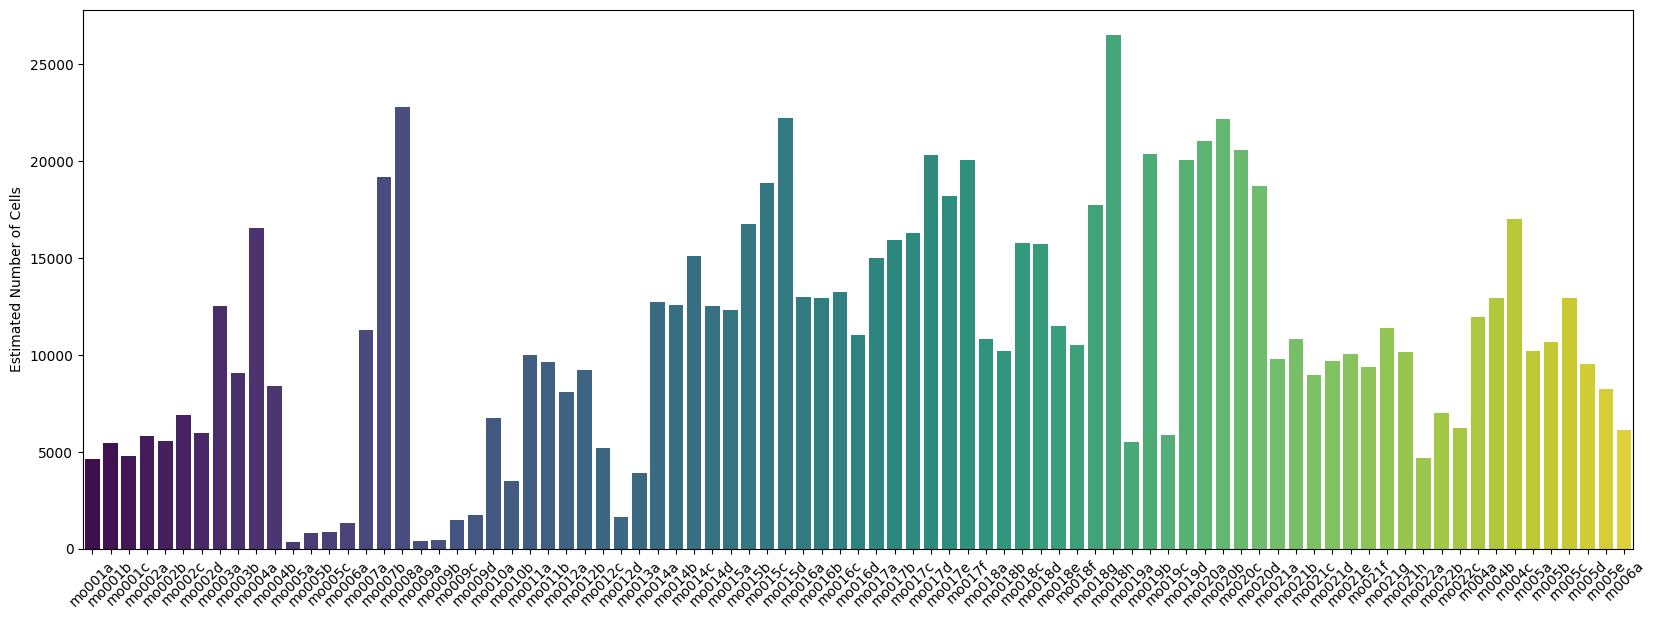

Mean Reads per Cell


/tmp/ipykernel_2562687/294347799.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x=x, y=y, palette='viridis')


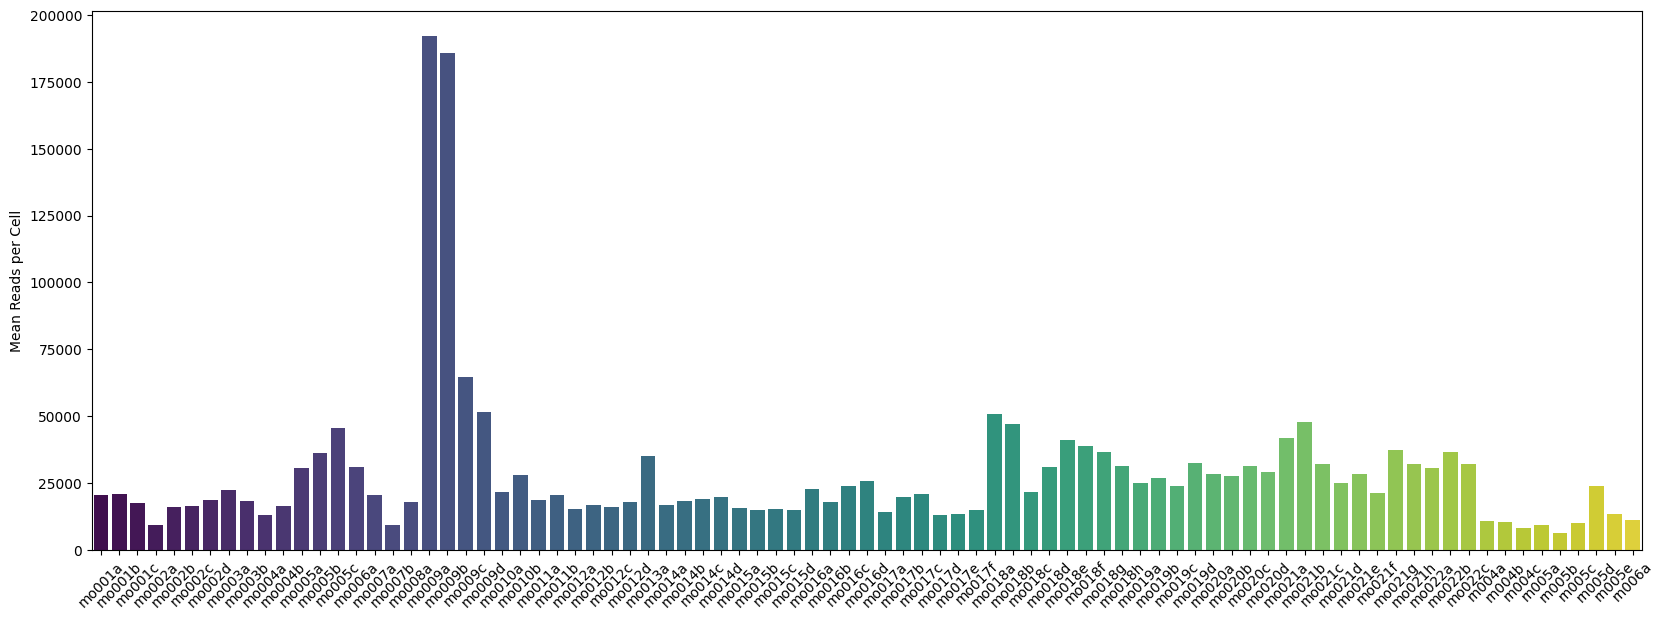

Median Genes per Cell


/tmp/ipykernel_2562687/294347799.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x=x, y=y, palette='viridis')


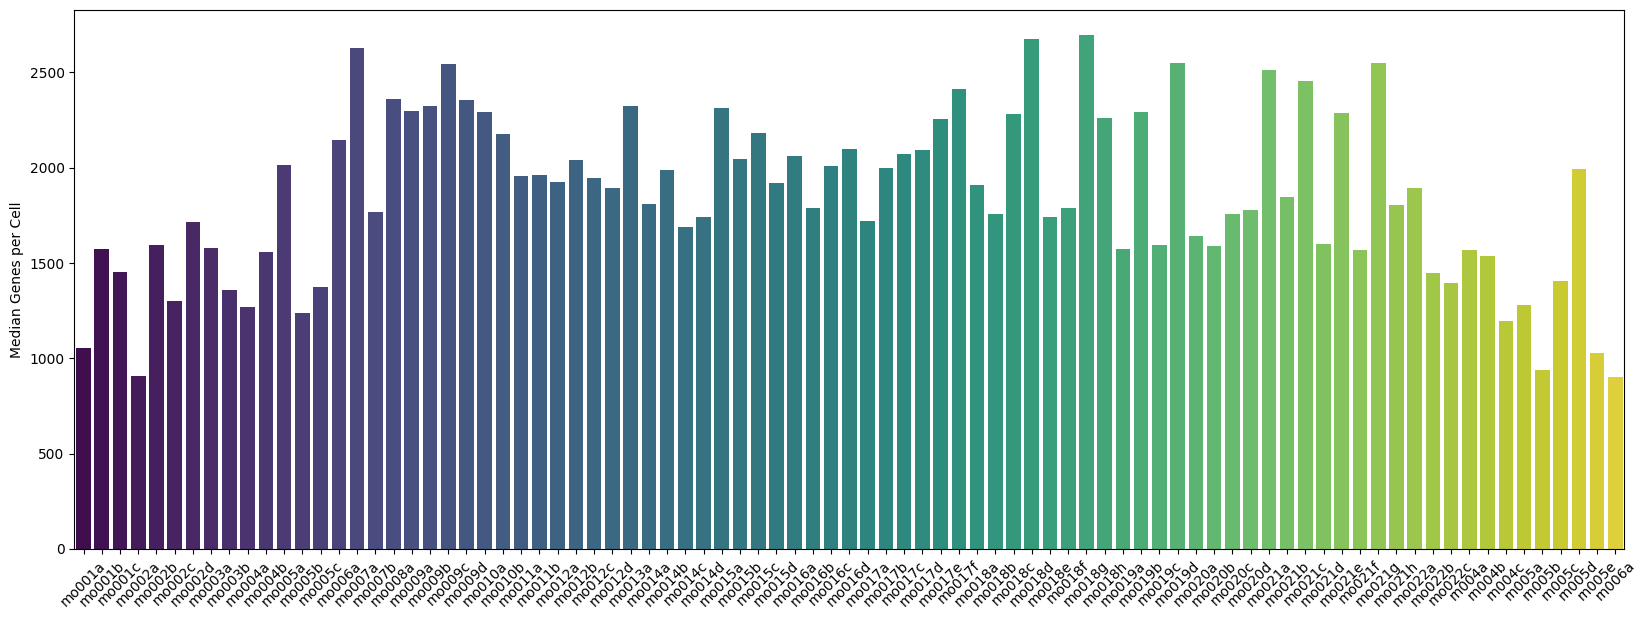

Number of Reads


/tmp/ipykernel_2562687/294347799.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x=x, y=y, palette='viridis')


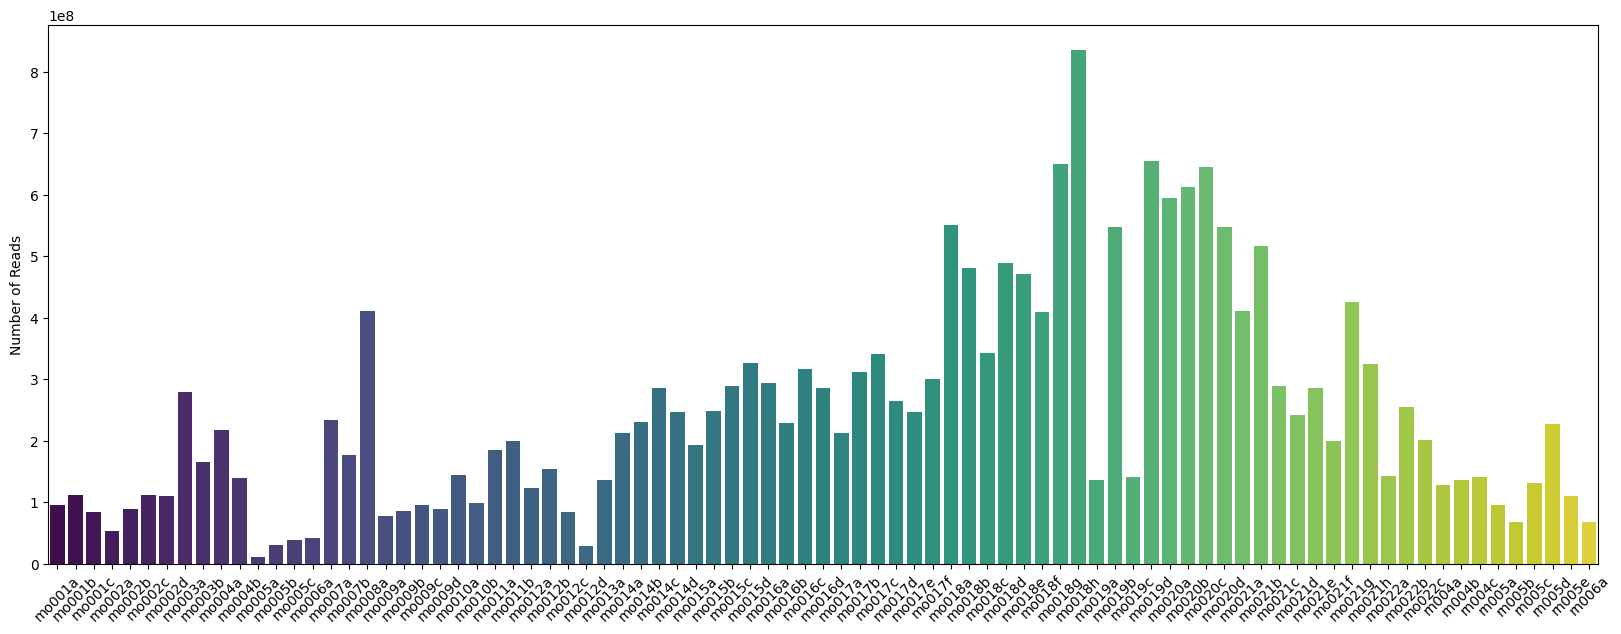

Valid Barcodes


/tmp/ipykernel_2562687/294347799.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x=x, y=y, palette='viridis')


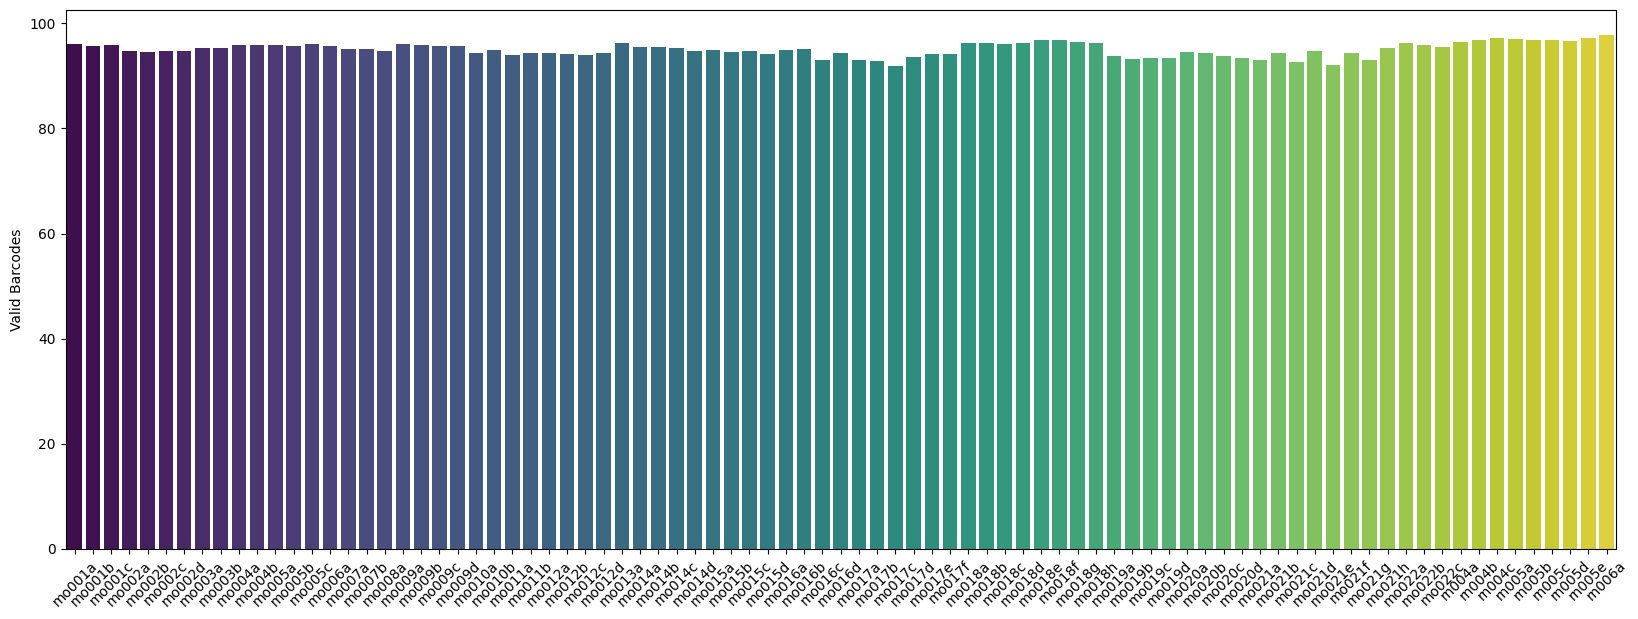

Sequencing Saturation


/tmp/ipykernel_2562687/294347799.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x=x, y=y, palette='viridis')


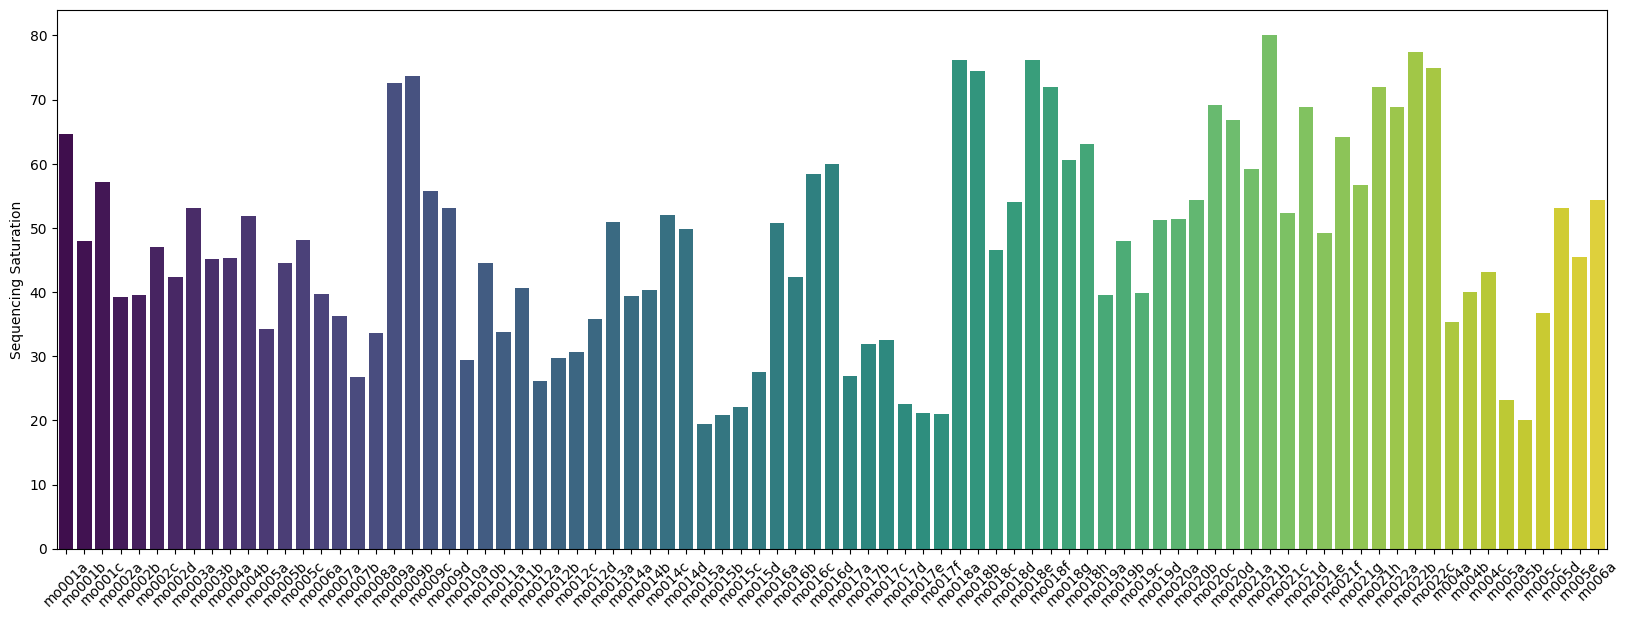

Q30 Bases in Barcode


/tmp/ipykernel_2562687/294347799.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x=x, y=y, palette='viridis')


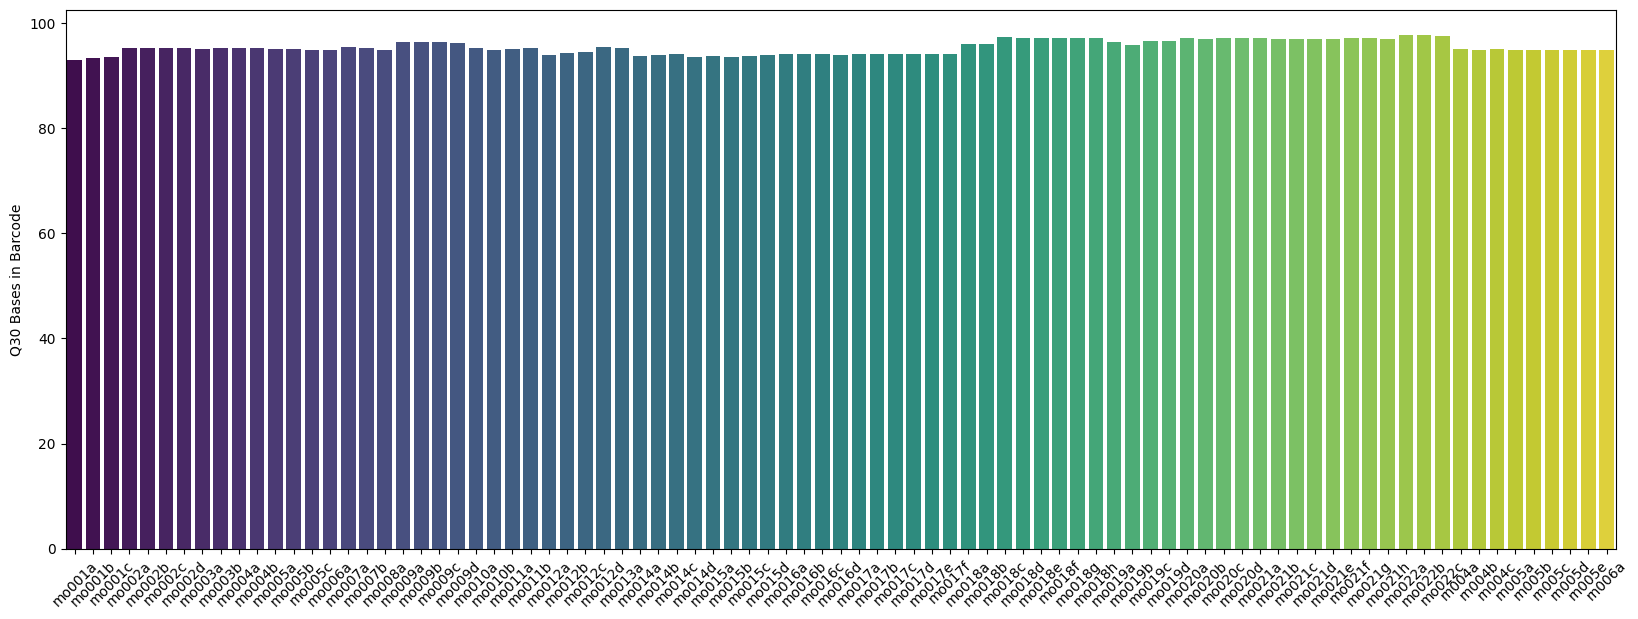

Q30 Bases in RNA Read


/tmp/ipykernel_2562687/294347799.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x=x, y=y, palette='viridis')


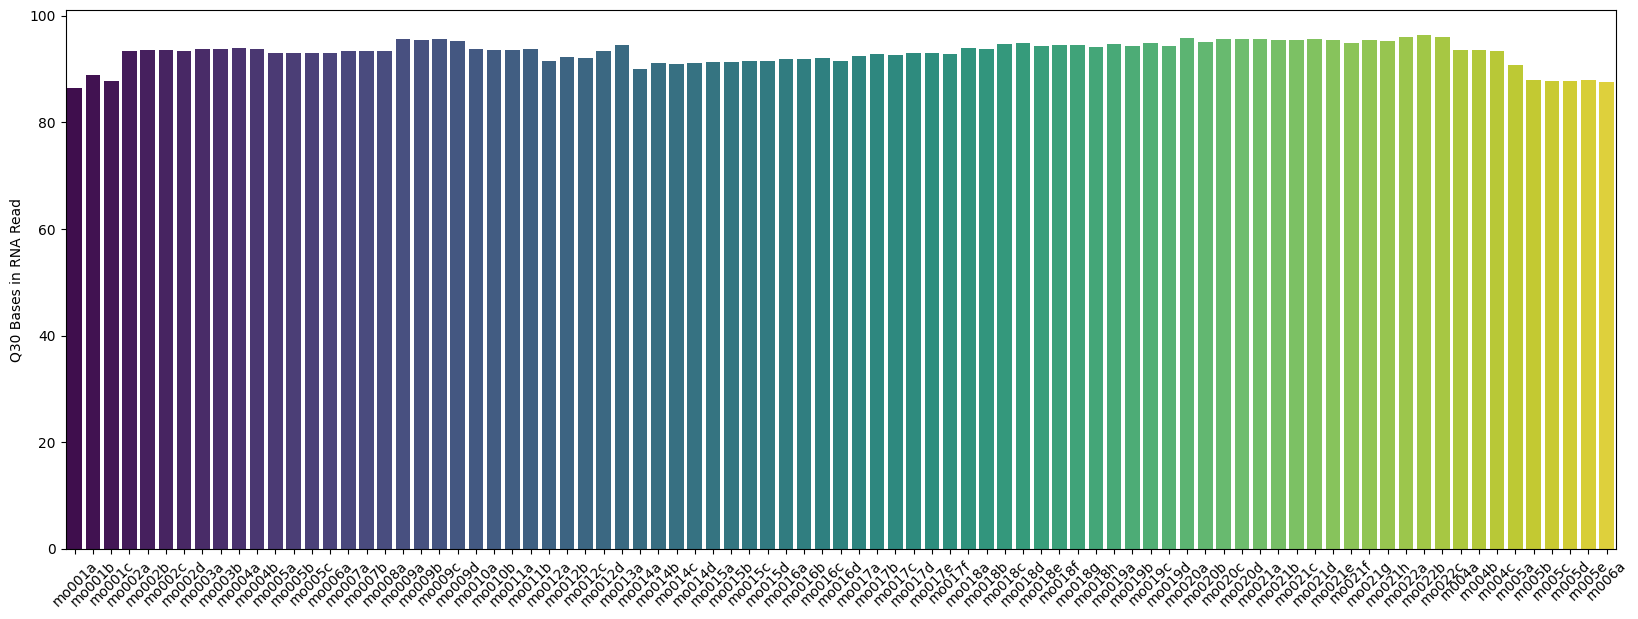

Q30 Bases in UMI


/tmp/ipykernel_2562687/294347799.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x=x, y=y, palette='viridis')


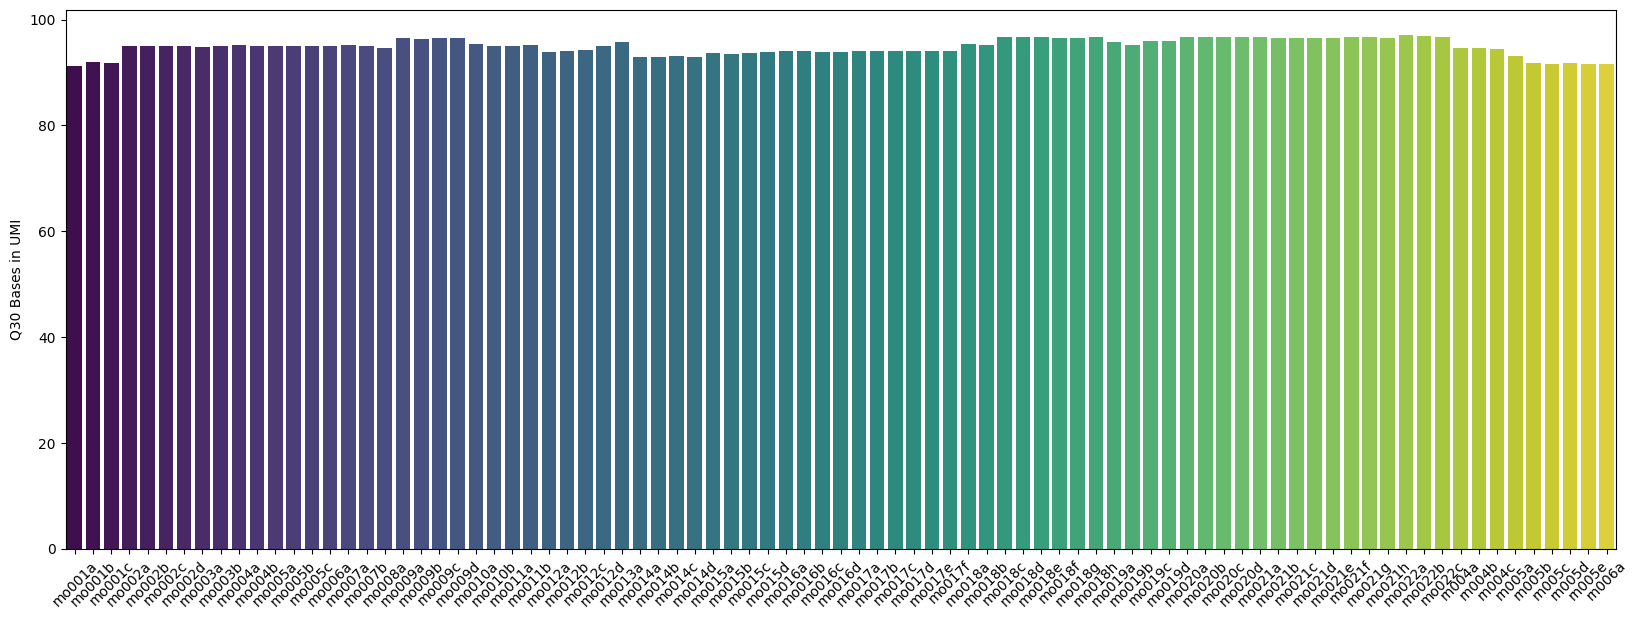

Reads Mapped to Genome


/tmp/ipykernel_2562687/294347799.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x=x, y=y, palette='viridis')


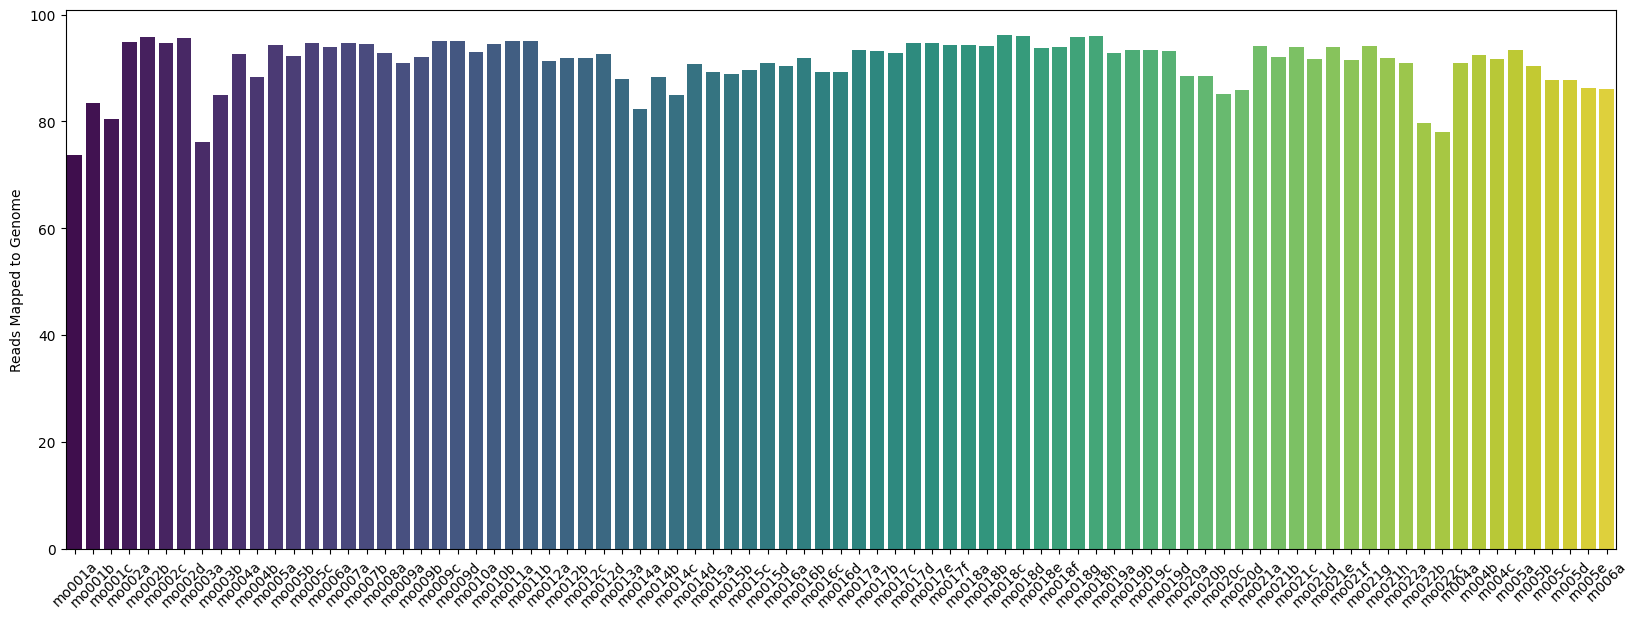

Reads Mapped Confidently to Genome


/tmp/ipykernel_2562687/294347799.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x=x, y=y, palette='viridis')


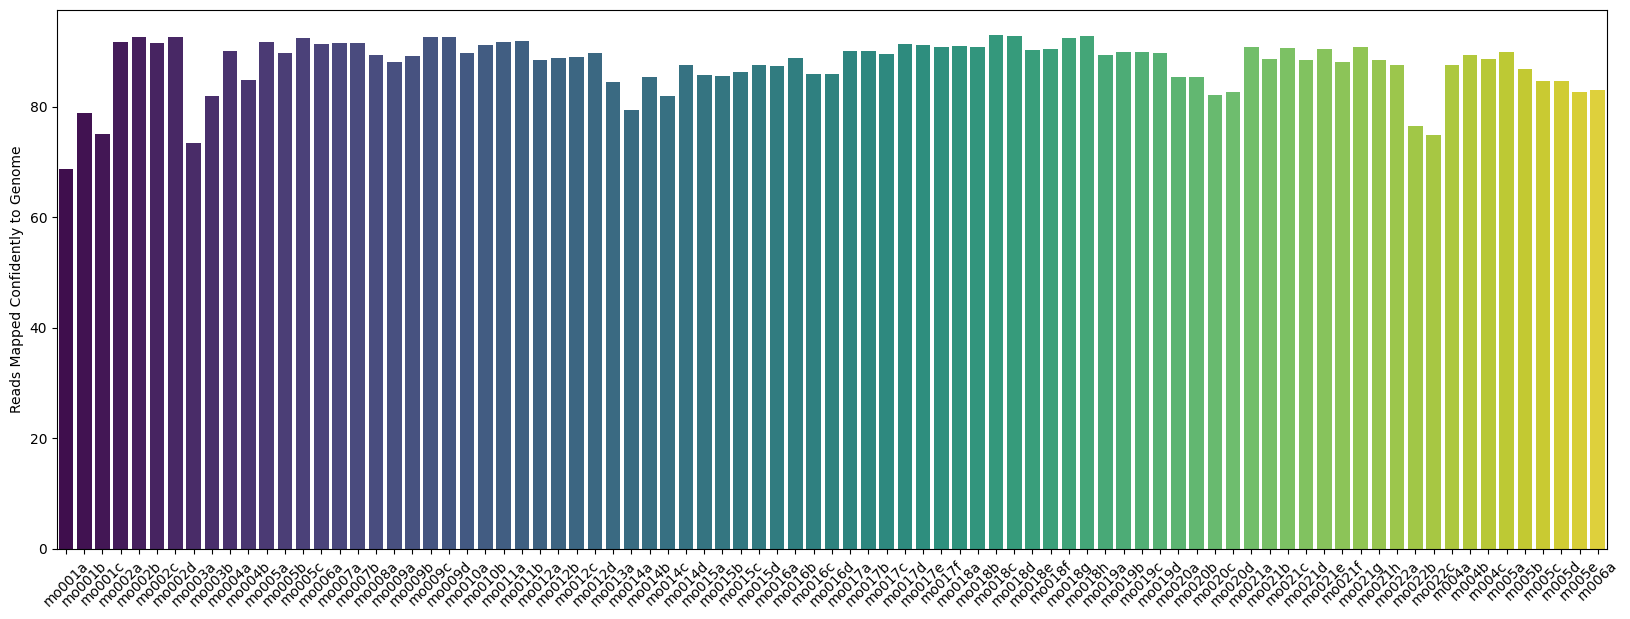

Reads Mapped Confidently to Intergenic Regions


/tmp/ipykernel_2562687/294347799.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x=x, y=y, palette='viridis')


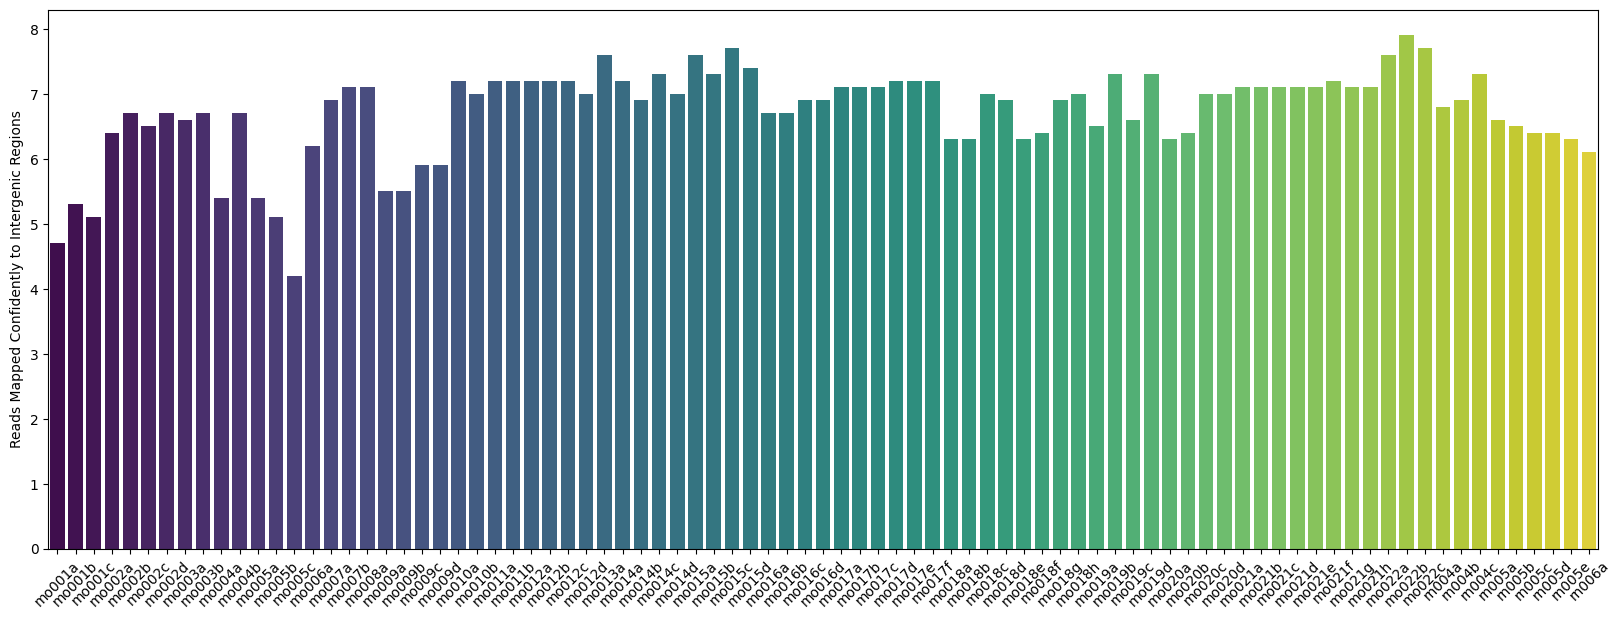

Reads Mapped Confidently to Intronic Regions


/tmp/ipykernel_2562687/294347799.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x=x, y=y, palette='viridis')


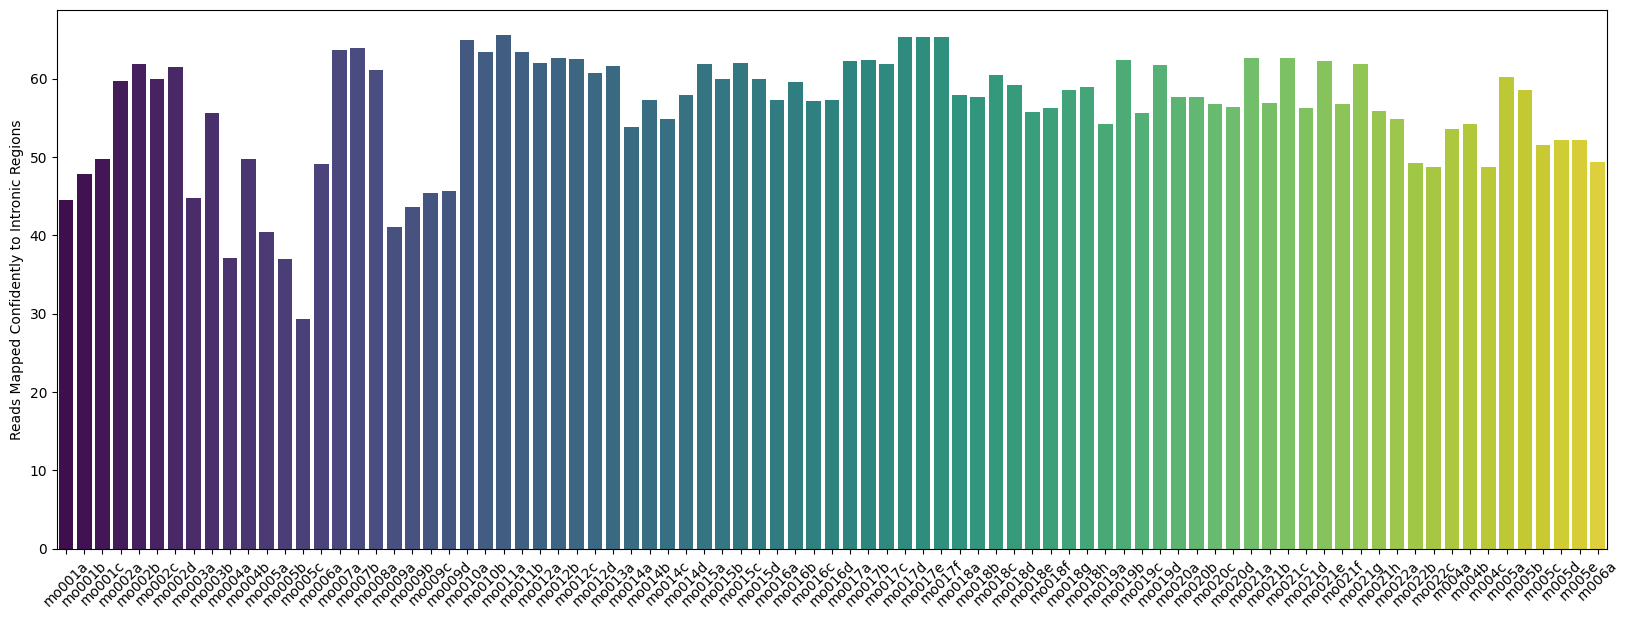

Reads Mapped Confidently to Exonic Regions


/tmp/ipykernel_2562687/294347799.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x=x, y=y, palette='viridis')


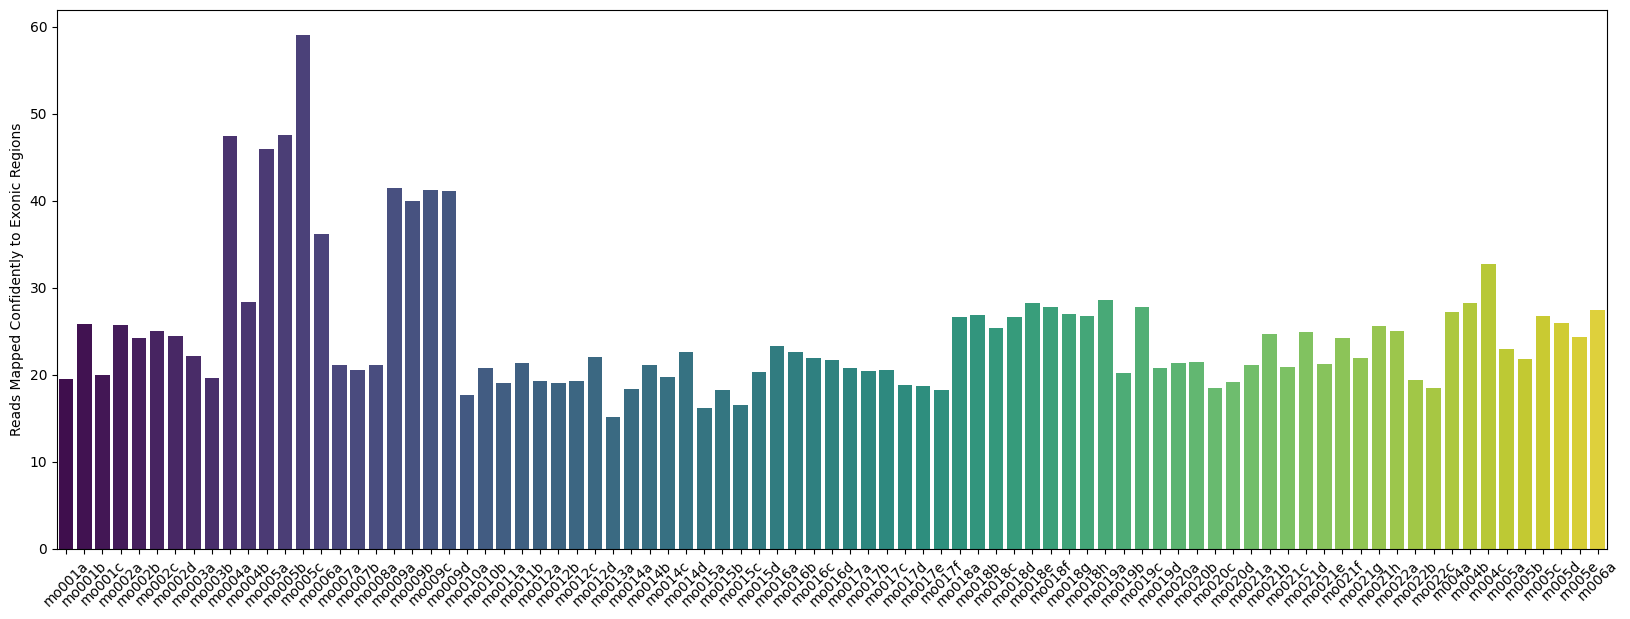

Reads Mapped Confidently to Transcriptome


/tmp/ipykernel_2562687/294347799.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x=x, y=y, palette='viridis')


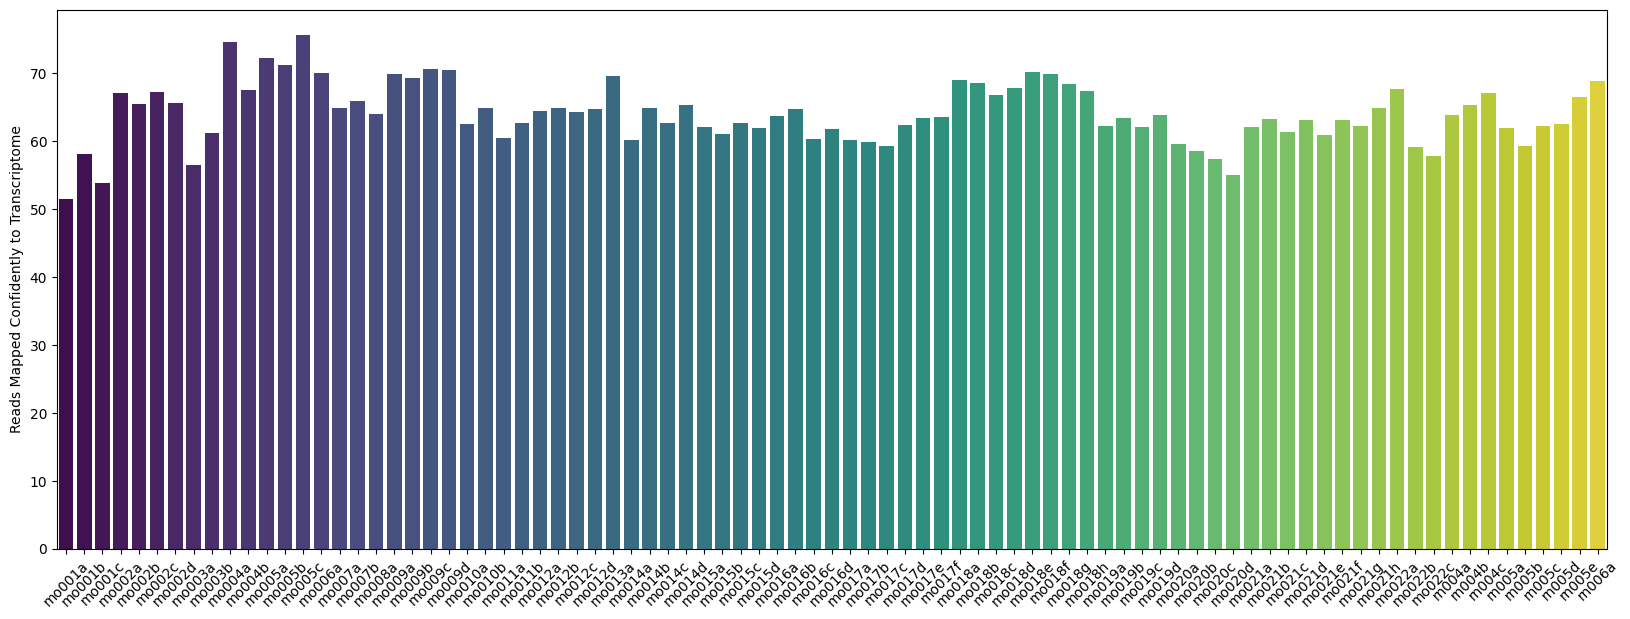

Reads Mapped Antisense to Gene


/tmp/ipykernel_2562687/294347799.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x=x, y=y, palette='viridis')


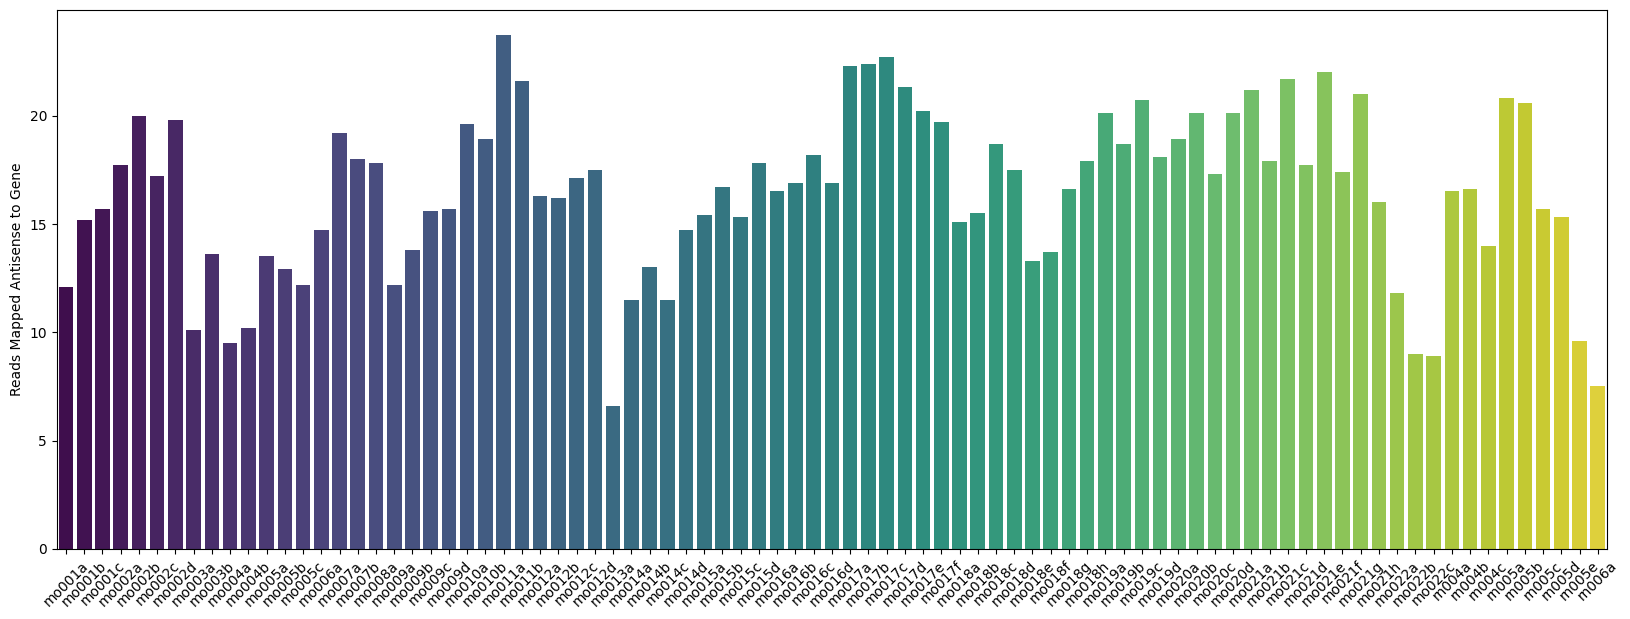

Fraction Reads in Cells


/tmp/ipykernel_2562687/294347799.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x=x, y=y, palette='viridis')


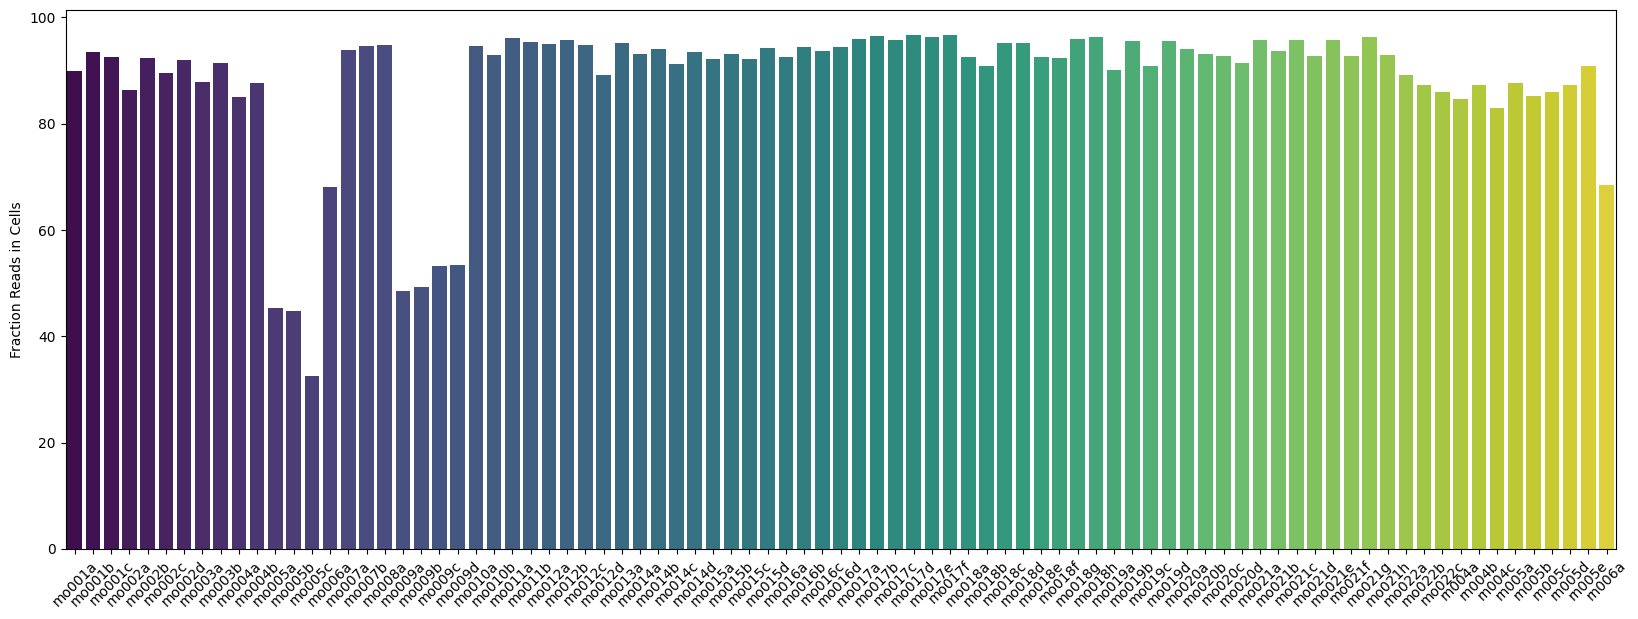

Total Genes Detected


/tmp/ipykernel_2562687/294347799.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x=x, y=y, palette='viridis')


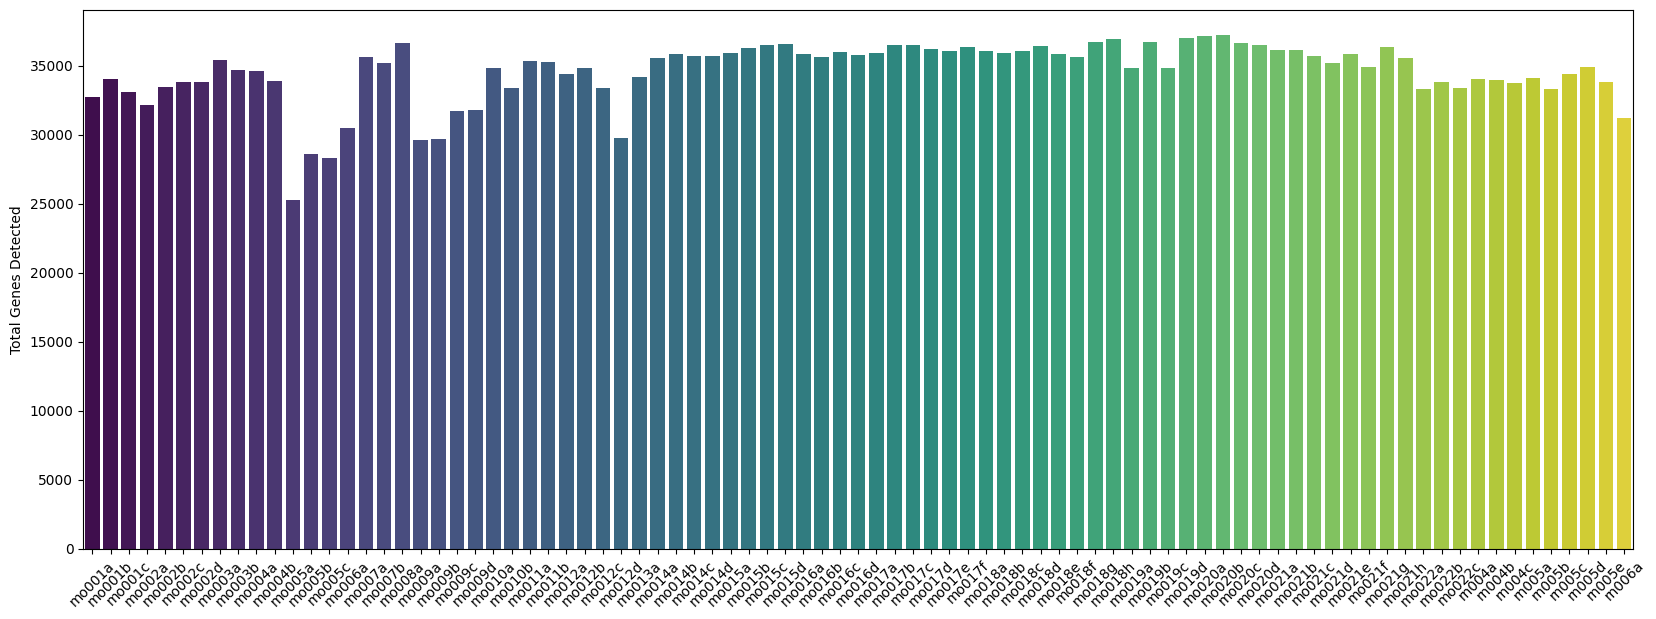

Median UMI Counts per Cell


/tmp/ipykernel_2562687/294347799.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x=x, y=y, palette='viridis')


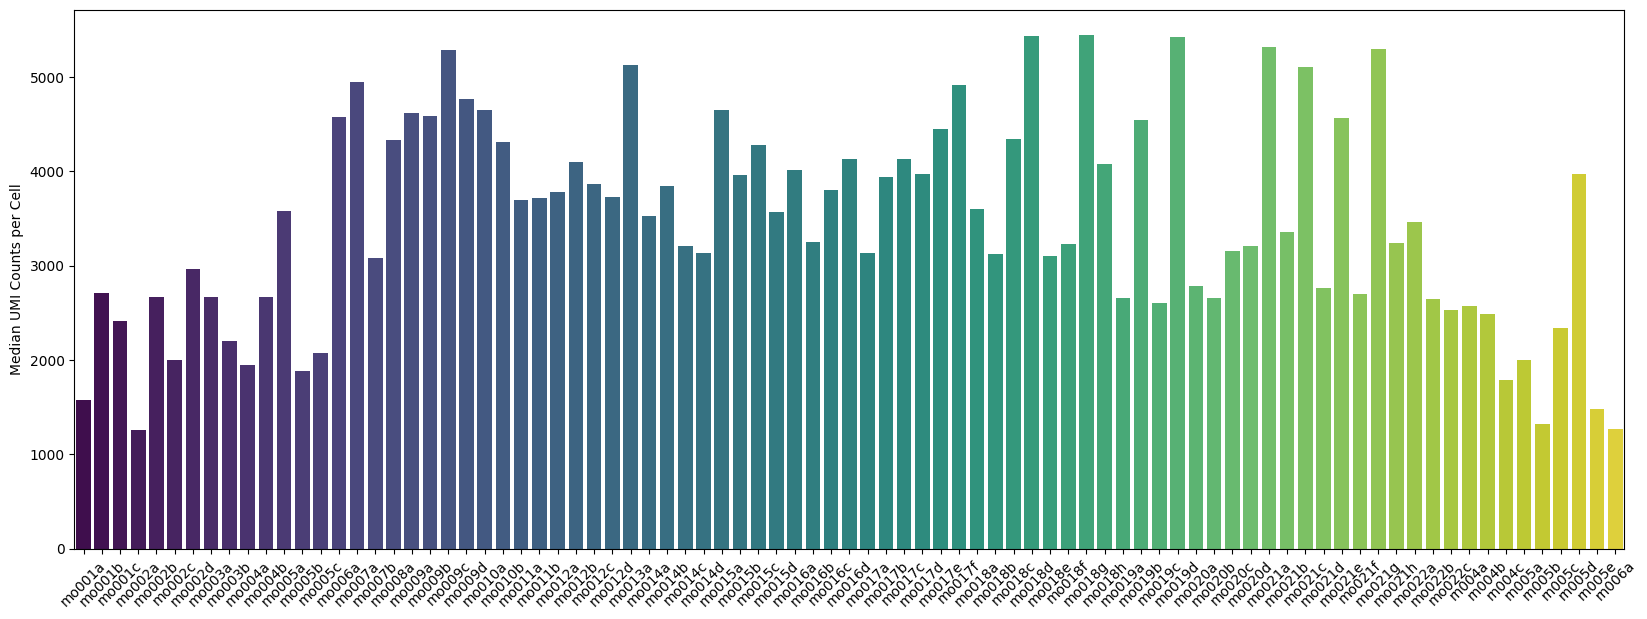

In [11]:
# Define plotting function
def plotting(df, x, y):
    plt.figure(figsize=(20, 7))
    sns.barplot(data=df, x=x, y=y, palette='viridis')
    plt.xticks(rotation=45)
    plt.xlabel("")
    plt.show()

#plotting(cellranger, "ID", "Mean Reads per Cell")

cols = cellranger.columns

# Loop through all the columns except for the first 3
for i in cols:  
    print(i)
    plotting(cellranger, cellranger.index , i)

In [12]:
pip list

Package                   Version
------------------------- --------------
absl-py                   2.1.0
aiobotocore               2.17.0
aiohappyeyeballs          2.4.4
aiohttp                   3.11.11
aiohttp-retry             2.9.1
aioitertools              0.12.0
aiosignal                 1.3.2
amqp                      5.3.1
anndata                   0.11.2
annotated-types           0.7.0
antlr4-python3-runtime    4.9.3
anyio                     4.8.0
appdirs                   1.4.4
argon2-cffi               23.1.0
argon2-cffi-bindings      21.2.0
array_api_compat          1.10.0
arrow                     1.3.0
asttokens                 3.0.0
async-lru                 2.0.4
asyncssh                  2.19.0
atpublic                  5.0
attrs                     24.3.0
babel                     2.16.0
beautifulsoup4            4.12.3
billiard                  4.2.1
biopython                 1.84
biothings-client          0.3.1
bleach                    6.2.0
boto3               